#### LOADING DATA FILE AND LIBRARIES

In [1]:
import pandas as pd
import numpy as np

In [2]:
acc = pd.read_csv("C:/Project/DATA/master_acc.csv", encoding="latin-1", low_memory=False,index_col="accident_id")

for col in acc.columns:
    print(f"\nColumn: {col}")
    print("Unique count:", acc[col].nunique())
    print("Sample unique values:", acc[col].dropna().unique()[:10])


Column: collision_label
Unique count: 7
Sample unique values: ['Side_two_vehicles' 'Other_collision' 'Rear_end_two_vehicles'
 'Frontal_two_vehicles' 'No_collision' 'Multiple_three_plus'
 'Chain_three_plus']

Column: is_weekend
Unique count: 2
Sample unique values: [False  True]

Column: season
Unique count: 4
Sample unique values: ['Winter' 'Spring' 'Summer' 'Autumn']

Column: surface_condition_label
Unique count: 4
Sample unique values: ['Normal' 'Wet' 'other' 'Unknown']

Column: manoeuvre_label
Unique count: 9
Sample unique values: ['Straight_ahead' 'Roundabout' 'other' 'Avoiding_obstacle' 'Interaction'
 'Park/Start/Stop' 'Reversing' 'Loss_of_control' 'Turning']

Column: sex_label
Unique count: 2
Sample unique values: ['Female' 'Male']

Column: user_category_label
Unique count: 4
Sample unique values: ['Driver' 'Pedestrian' 'Passenger' 'other']

Column: injury_severity_label
Unique count: 4
Sample unique values: ['Uninjured' 'Injured_Hospitalized' 'Killed' 'Injured_Slight']

Column:

In [3]:
### Fixing Nans in target
print(acc["injury_severity_label"].isna().sum())

# Drop rows with missing target
acc = acc.dropna(subset=["injury_severity_label"])

print("Remaining rows:", acc.shape[0])


21357
Remaining rows: 1412032


In [4]:
print(acc.shape)
print(acc.columns)

(1412032, 27)
Index(['collision_label', 'is_weekend', 'season', 'surface_condition_label',
       'manoeuvre_label', 'sex_label', 'user_category_label',
       'injury_severity_label', 'seat_position_label', 'journey_purpose_label',
       'is_holiday', 'age', 'age_group', 'seatbelt_used', 'helmet_used',
       'any_protection_used', 'protection_effective', 'vehicle_group',
       'impact_group', 'motorcycle_side_impact', 'is_night', 'is_urban',
       'lane_width', 'road_group', 'weather_group', 'day_of_week',
       'hour_group'],
      dtype='object')


### MODELLING PREPROCESSING

#### Handle Remaining NaNs

In [5]:
from sklearn.model_selection import train_test_split

X = acc.drop(columns=["injury_severity_label"])
y = acc["injury_severity_label"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1129625, 26) Test size: (282407, 26)


In [6]:
from sklearn.impute import SimpleImputer

# Numeric columns
numeric_cols = ["age", "lane_width"]

num_imputer = SimpleImputer(strategy="median")
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season"
]

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Check again for NaNs
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 1591
Remaining NaNs in test: 398


In [7]:
# Show which columns still have NaNs
print("Train NaNs per column:\n", X_train.isna().sum()[X_train.isna().sum() > 0])
print("\nTest NaNs per column:\n", X_test.isna().sum()[X_test.isna().sum() > 0])

Train NaNs per column:
 age_group    1591
dtype: int64

Test NaNs per column:
 age_group    398
dtype: int64


In [8]:
# Ensure dtype is categorical
X_train["age_group"] = X_train["age_group"].astype("category")
X_test["age_group"] = X_test["age_group"].astype("category")

# Add "Unknown" to categories if not already present
if "Unknown" not in X_train["age_group"].cat.categories:
    X_train["age_group"] = X_train["age_group"].cat.add_categories(["Unknown"])
    X_test["age_group"] = X_test["age_group"].cat.add_categories(["Unknown"])

# Fill NaNs with "Unknown"
X_train["age_group"] = X_train["age_group"].fillna("Unknown")
X_test["age_group"] = X_test["age_group"].fillna("Unknown")

# Final check
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 0
Remaining NaNs in test: 0


#### Encoding Categorical Features

In [9]:
from sklearn.preprocessing import OneHotEncoder

# Define categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season", "age_group"
]

# Initialize encoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit on train, transform both train and test
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (1129625, 74)
Encoded test shape: (282407, 74)


#### Scale Numeric Features

In [10]:
from sklearn.preprocessing import StandardScaler

# Numeric columns
numeric_cols = ["age", "lane_width"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (1129625, 2)
Scaled test shape: (282407, 2)


#### Combine All Features

In [11]:
import numpy as np

# Binary columns
binary_cols = [
    "is_weekend", "is_holiday", "seatbelt_used", "helmet_used",
    "any_protection_used", "protection_effective",
    "motorcycle_side_impact", "is_night", "is_urban"
]

# Combine all parts
X_train_final = np.hstack([
    X_train_scaled,          # numeric
    X_train_encoded,         # categorical
    X_train[binary_cols].values  # binary flags
])

X_test_final = np.hstack([
    X_test_scaled,
    X_test_encoded,
    X_test[binary_cols].values
])

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (1129625, 85)
Final test shape: (282407, 85)


#### Encoding Target Labels 

In [12]:
# Encoding Target Labels (y_train & y_test)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

### LAZYPREDICT

In [ ]:
from lazypredict.Supervised import LazyClassifier, CLASSIFIERS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Prepare data
X_lazy = pd.DataFrame(X_train_final)
y_lazy = y_train
X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy = train_test_split(
    X_lazy, y_lazy, test_size=0.2, random_state=42
)

# Heavy models to skip
heavy = {
    "SVC","NuSVC","QuadraticDiscriminantAnalysis",
    "LabelPropagation","LabelSpreading",
    "SelfTrainingClassifier","StackingClassifier",
    "GaussianProcessClassifier","MLPClassifier"
}

# Filter CLASSIFIERS (list of tuples) by name
safe_classifiers = [(name, model) for name, model in CLASSIFIERS if name not in heavy]

# Initialize LazyClassifier with filtered list
clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=accuracy_score,
    classifiers=safe_classifiers
)

models, predictions = clf.fit(X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy)
print(models)


### Performance Comparisons of top 5 Models with Benchmarking 

In [ ]:
# Running all five models separately in the order of quickest first → heaviest last 
# by benchmarking all five models on a 200k sample

#Create a 200k sample from your training set

#Wrap your numpy array in a DataFrame
X_df = pd.DataFrame(X_train_final)
y_series = pd.Series(y_train_enc)

#Now you can sample
X_sample = X_df.sample(200000, random_state=42)
y_sample = y_series.loc[X_sample.index]

#Use the same CV and scorers
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

#### 1. RidgeClassifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

ridge = RidgeClassifier(alpha=1.0)
out = cross_validate(ridge, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "RidgeClassifier",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

#### 2. LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=300, solver="saga", n_jobs=-1, class_weight="balanced")
out = cross_validate(logreg, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LogisticRegression",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

#### 3. LinearDiscriminantAnalysis

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
out = cross_validate(lda, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LinearDiscriminantAnalysis",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

#### 4. LightGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    force_row_wise=True
)
out = cross_validate(lgbm, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LGBMClassifier",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

#### 5. CalibratedClassifierCV

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

base = LogisticRegression(max_iter=300, solver="saga", n_jobs=-1, class_weight="balanced")
calib = CalibratedClassifierCV(estimator=base, cv=3)
out = cross_validate(calib, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "CalibratedClassifierCV",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

#### Visualization for Models Performances

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve  

# -----------------------------
# Results data (from your 200k sample)
# -----------------------------
results = pd.DataFrame([
    {"Model": "RidgeClassifier", "Accuracy": 0.542, "F1": 0.510, "Balanced": 0.541},
    {"Model": "LogisticRegression", "Accuracy": 0.550, "F1": 0.534, "Balanced": 0.549},
    {"Model": "LinearDiscriminantAnalysis", "Accuracy": 0.544, "F1": 0.531, "Balanced": 0.544},
    {"Model": "LGBMClassifier", "Accuracy": 0.674, "F1": 0.662, "Balanced": 0.673},
    {"Model": "CalibratedClassifierCV", "Accuracy": 0.548, "F1": 0.517, "Balanced": 0.547}
])

palette = sns.color_palette("Set2", n_colors=3)

# -----------------------------
# 1) Bar chart: Accuracy, F1, Balanced
# -----------------------------
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette=palette)
plt.title("Model performance comparison (Accuracy, F1 macro, Balanced Accuracy)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.45, 0.75)
plt.ylabel("Score")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Boxplots: distribution across folds (synthetic spread for demo)
# Replace with real per-fold scores if you have them.
# -----------------------------
np.random.seed(42)
fold_scores = pd.DataFrame({
    "Model": np.repeat(results["Model"].values, 3),
    "Accuracy": np.concatenate([np.random.normal(m, 0.01, 3) for m in results["Accuracy"]]),
    "F1": np.concatenate([np.random.normal(m, 0.01, 3) for m in results["F1"]])
})

plt.figure(figsize=(10,6))
sns.boxplot(data=fold_scores, x="Model", y="Accuracy")
sns.stripplot(data=fold_scores, x="Model", y="Accuracy", color="black", alpha=0.5)
plt.title("Accuracy distribution across folds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=fold_scores, x="Model", y="F1")
sns.stripplot(data=fold_scores, x="Model", y="F1", color="black", alpha=0.5)
plt.title("F1 macro distribution across folds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### DATA MODELING (LR & LGBM) - (Original Features (85))

#### LR - X_train_final, y_train_final (_,85)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# LogisticRegression on X_train_final with scaling and higher max_iter
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,          # allow more iterations for convergence
        solver="lbfgs",         # faster, stable solver for dense data
        n_jobs=-1,
        class_weight="balanced" # handle imbalance without oversampling
    )
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

out = cross_validate(logreg, X_train_final, y_train_enc, cv=cv, scoring=scorers)

print({
    "Model": "LogisticRegression",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

{'Model': 'LogisticRegression', 'Mean Accuracy': np.float64(0.5660002213123825), 'Mean F1': np.float64(0.4445669442698347), 'Mean Balanced Acc': np.float64(0.5367700413811778)}


#### LGBM - X_train_final, y_train_final (_,85)

In [13]:
#Recovering feature names

# Get categorical feature names from the encoder
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)

# Numeric + binary names
numeric_feature_names = numeric_cols
binary_feature_names = binary_cols

# Combine all names
feature_names = list(numeric_feature_names) + list(categorical_feature_names) + list(binary_feature_names)

# Replace whitespace with underscores
feature_names = [name.replace(" ", "_") for name in feature_names]

# Wrap X_train_lgbm into a DataFrame with names
import pandas as pd
X_train_lgbm = pd.DataFrame(X_train_final, columns=feature_names)
X_test_lgbm = pd.DataFrame(X_test_final, columns=feature_names)

In [14]:
#LightGBM training 

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix


lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=True,
    force_row_wise=True
)
lgbm.fit(X_train_lgbm, y_train_enc)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

out = cross_validate(lgbm, X_train_lgbm, y_train_enc, cv=cv, scoring=scorers)

print({
    "Model": "LightGBM",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

# Predict on test set
y_pred = lgbm.predict(X_test_lgbm)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred))

# Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred))


[LightGBM] [Info] Total Bins 513
[LightGBM] [Info] Number of data points in the train set: 1129625, number of used features: 85
[LightGBM] [Info] Start training from score -1.658970
[LightGBM] [Info] Start training from score -1.134993
[LightGBM] [Info] Start training from score -3.674034
[LightGBM] [Info] Start training from score -0.770316
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658968
[LightGBM] [Info] Start training from score -1.134990
[LightGBM] [Info] Start training from score -3.674051
[LightGBM] [Info] Start training from score -0.770318
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658974
[LightGBM] [Info] Start training from score -1.134994
[LightGBM] [Info] Start training from score -3.674008
[LightGBM] [Info] Start 

### TRAINING LGBM (SMOTE & Controlled SMOTE) (85) - Comparison

In [17]:
# SMOTE Integration

from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE only on training set
smote85 = SMOTE(random_state=42)

X_train_s85, y_train_s85 = smote85.fit_resample(X_train_final, y_train_enc)

# Check new class distribution
print("\nOriginal shape of X_train :",X_train_final.shape)
print("\nSMOTE shape of X_train :",X_train_s85.shape)

print("Original class distribution:", Counter(y_train_enc))
print("SMOTE Balanced class distribution:", Counter(y_train_s85))



Original shape of X_train : (1129625, 85)

SMOTE shape of X_train : (2091464, 85)
Original class distribution: Counter({np.int64(3): 522866, np.int64(1): 363089, np.int64(0): 215007, np.int64(2): 28663})
SMOTE Balanced class distribution: Counter({np.int64(3): 522866, np.int64(0): 522866, np.int64(2): 522866, np.int64(1): 522866})


In [15]:
# Controlled SMOTE Integration

from imblearn.over_sampling import SMOTE

csmote85 = SMOTE(
    sampling_strategy={
        0: 215007,   # keep class 0 at its original size
        1: 363089,   # keep class 1 at its original size
        2: 150000,   # moderately oversample class 2 (instead of 522k)
        3: 522866    # majority class stays as is
    },
    random_state=42
)

X_train_cs85, y_train_cs85 = csmote85.fit_resample(X_train_final, y_train_enc)

print("\nOriginal shape of X_train :",X_train_final.shape)
print("\nControlled SMOTE shape of X_train :",X_train_cs85.shape)

print("\nOriginal class distribution of y_train :",np.bincount(y_train_enc))
print("\nControlled SMOTE class distribution of y_train :",np.bincount(y_train_cs85))



Original shape of X_train : (1129625, 85)

Controlled SMOTE shape of X_train : (1250962, 85)

Original class distribution of y_train : [215007 363089  28663 522866]

Controlled SMOTE class distribution of y_train : [215007 363089 150000 522866]


In [18]:
# Training and Comparing LGBM on SMOTE and Controlled SMOTE for Original 85 Features

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ---------------------------------------------------------
# Helper function to train and evaluate a model
# ---------------------------------------------------------
def train_and_evaluate(X_train, y_train, X_test, y_test, model_name):
    print(f"\n==================== {model_name} ====================")

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        is_unbalance=True,
        force_row_wise=True
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model


# ---------------------------------------------------------
# Train on Plain SMOTE (85 features)
# ---------------------------------------------------------
lgbm_s85 = train_and_evaluate(
    X_train_s85, y_train_s85,
    X_test_lgbm, y_test_enc,
    model_name="LightGBM (Plain SMOTE - 85 features)"
)

# ---------------------------------------------------------
# Train on Controlled SMOTE (85 features)
# ---------------------------------------------------------
lgbm_cs85 = train_and_evaluate(
    X_train_cs85, y_train_cs85,
    X_test_lgbm, y_test_enc,
    model_name="LightGBM (Controlled SMOTE - 85 features)"
)


==================== LightGBM (Plain SMOTE - 85 features) ====================
[LightGBM] [Info] Total Bins 20912
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 85
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.44      0.47     53752
           1       0.61      0.52      0.56     90772
           2       0.31      0.08      0.13      7166
           3       0.72      0.86      0.78    130717

    accuracy                           0.65    282407
   macro avg       0.54      0.47      0.48    282407
weighted avg       0.63      0.65      0.63    282407


Confusion Matrix:
[[ 23519  17652    834  11747]
 [ 12705  46788    194  31085]
 [  4426    870    573   1297]
 [ 

### Modeling Optimization with Feature Importance, PCA, SMOTE & Controlled SMOTE (60) 

#### Extracting Feature Importance and Subsetting (85->60)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.112192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 1129625, number of used features: 85
[LightGBM] [Info] Start training from score -1.658970
[LightGBM] [Info] Start training from score -1.134993
[LightGBM] [Info] Start training from score -3.674034
[LightGBM] [Info] Start training from score -0.770316
age                                       2051
lane_width                                1925
collision_label_Other_collision           1233
is_urban                                  1019
impact_group_Rear                          639
collision_label_No_collision               631
vehicle_group_Motorcycle                   558
sex_label_Female                           552
manoeuvre_label_Avoiding_obstacle          548
collisi

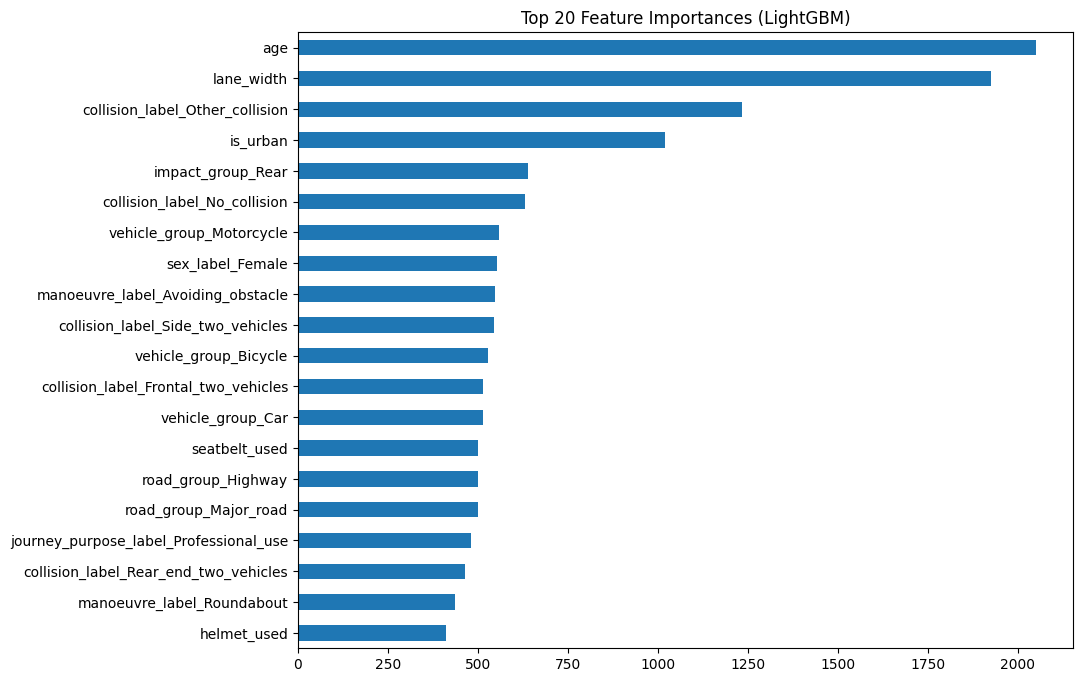

In [18]:
#Training a quick LightGBM model and Extracting Feature Importance 

from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

lgb.fit(X_train_final, y_train_enc)

# Extracting feature importances
import pandas as pd

importances = pd.Series(
    lgb.feature_importances_,
    index=feature_names
)

importances = importances.sort_values(ascending=False)
print(importances.head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (LightGBM)")
plt.show()



In [19]:
# Select features with importance >= 100
selected_features = importances[importances >= 100]

print("Number of selected features:", len(selected_features))
print(selected_features)

# Subsetting training and test arrays to these features

selected_feature_names = selected_features.index.tolist()
print(len(selected_feature_names))
print(selected_feature_names)

import pandas as pd

X_train_df = pd.DataFrame(X_train_final, columns=feature_names)
X_test_df = pd.DataFrame(X_test_final, columns=feature_names)

X_train_sel = X_train_df[selected_feature_names]
X_test_sel = X_test_df[selected_feature_names]

print(X_train_sel.shape)
print(X_test_sel.shape)

Number of selected features: 60
age                                       2051
lane_width                                1925
collision_label_Other_collision           1233
is_urban                                  1019
impact_group_Rear                          639
collision_label_No_collision               631
vehicle_group_Motorcycle                   558
sex_label_Female                           552
manoeuvre_label_Avoiding_obstacle          548
collision_label_Side_two_vehicles          545
vehicle_group_Bicycle                      527
collision_label_Frontal_two_vehicles       515
vehicle_group_Car                          514
seatbelt_used                              501
road_group_Highway                         500
road_group_Major_road                      499
journey_purpose_label_Professional_use     481
collision_label_Rear_end_two_vehicles      463
manoeuvre_label_Roundabout                 436
helmet_used                                412
hour_group_Night            

#### Scaling and PCA Implementation (60->30)

In [20]:
#Scaling the 60 selected features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# PCA IMPLEMENTATION

from sklearn.decomposition import PCA

# Fit PCA on training data only
pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca= pca.transform(X_test_scaled)

pca.explained_variance_ratio_.sum()

np.float64(0.7794588358740355)

#### SMOTE and Controlled SMOTE on PCA (30)

In [21]:
#SMOTE on PCA (30 Features)

# SMOTE Integration
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE only on training set
smote_pca = SMOTE(random_state=42)

X_train_s30, y_train_s30 = smote_pca.fit_resample(X_train_pca,y_train_enc)

# Check new class distribution
print("\n==================== SMOTE on PCA (30 Features) ====================")

print("\nOriginal PCA shape of X_train :",X_train_pca.shape)
print("\nPCA SMOTE shape of X_train :",X_train_s30.shape)

print("\nOriginal class distribution:", Counter(y_train_enc))
print("\nPCA SMOTE class distribution:", Counter(y_train_s30))

#Controlled-SMOTE on PCA (30 Features)

from imblearn.over_sampling import SMOTE

csmote_pca = SMOTE(
    sampling_strategy={
        0: 215007,   # keep class 0 at its original size
        1: 363089,   # keep class 1 at its original size
        2: 150000,   # moderately oversample class 2 (instead of 522k)
        3: 522866    # majority class stays as is
    },
    random_state=42
)

X_train_cs30, y_train_cs30 = csmote_pca.fit_resample(X_train_pca, y_train_enc)

print("\n==================== CONTROLLED-SMOTE on PCA (30 Features) ====================")

print("\nOriginal PCA shape of X_train :",X_train_pca.shape)
print("\nPCA CONTROLLED-SMOTE shape of X_train :",X_train_cs30.shape)

print("\nOriginal class distribution of y_train :",np.bincount(y_train_enc))
print("\nPCA CONTROLLED-SMOTE class distribution of y_train :",np.bincount(y_train_cs30))




==================== SMOTE on PCA (30 Features) ====================

Original PCA shape of X_train : (1129625, 30)

PCA SMOTE shape of X_train : (2091464, 30)

Original class distribution: Counter({np.int64(3): 522866, np.int64(1): 363089, np.int64(0): 215007, np.int64(2): 28663})

PCA SMOTE class distribution: Counter({np.int64(3): 522866, np.int64(0): 522866, np.int64(2): 522866, np.int64(1): 522866})

==================== CONTROLLED-SMOTE on PCA (30 Features) ====================

Original PCA shape of X_train : (1129625, 30)

PCA CONTROLLED-SMOTE shape of X_train : (1250962, 30)

Original class distribution of y_train : [215007 363089  28663 522866]

PCA CONTROLLED-SMOTE class distribution of y_train : [215007 363089 150000 522866]


#### Inverse transform on SMOTE and Controlled-SMOTE to original feature space (30->60)

In [22]:
# Inverse transform SMOTE output back to original feature space
X_train_s60 = pca.inverse_transform(X_train_s30)

print(X_train_s60.shape)
print(X_train_scaled.var(axis=0).mean())
print(X_train_s60.var(axis=0).mean())

# Build final DataFrames with feature names

X_train_s60 = pd.DataFrame(X_train_s60, columns=selected_feature_names)
y_train_s60 = pd.Series(y_train_s30)


(2091464, 60)
0.9999999999991722
0.7938001942314087


In [23]:
# Inverse transform CONTROLLED-SMOTE output back to original feature space
X_train_cs60 = pca.inverse_transform(X_train_cs30)

print(X_train_cs60.shape)
print(X_train_scaled.var(axis=0).mean())
print(X_train_cs60.var(axis=0).mean())

# Build final DataFrames with feature names

X_train_cs60 = pd.DataFrame(X_train_cs60, columns=selected_feature_names)
y_train_cs60 = pd.Series(y_train_cs30)

(1250962, 60)
0.9999999999991722
0.7840838620721768


In [24]:
# Inverse transform X_test to original feature space

X_test_pca_inverse = pca.inverse_transform(X_test_pca)
X_test_pca_final = pd.DataFrame(X_test_pca_inverse, columns=selected_feature_names)


### TRAINING LGBM (SMOTE & Controlled SMOTE) (60) - Comparison

In [25]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------------------------------------
# Helper function to train and evaluate a model
# ---------------------------------------------------------
def train_and_evaluate(X_train, y_train, X_test, y_test, model_name):
    print(f"\n==================== {model_name} ====================")

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        is_unbalance=True,
        force_row_wise=True
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model


# ---------------------------------------------------------
# Train on Plain SMOTE (PCA 60 features)
# ---------------------------------------------------------
lgbm_s60 = train_and_evaluate(
    X_train_s60, y_train_s60,
    X_test_pca_final, y_test_enc,
    model_name="LightGBM (Plain SMOTE - PCA 60 features)"
)

# ---------------------------------------------------------
# Train on Controlled SMOTE (PCA 60 features)
# ---------------------------------------------------------
lgbm_cs60 = train_and_evaluate(
    X_train_cs60, y_train_cs60,
    X_test_pca_final, y_test_enc,
    model_name="LightGBM (Controlled SMOTE - PCA 60 features)"
)


==================== LightGBM (Plain SMOTE - PCA 60 features) ====================
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 60
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.36      0.40     53752
           1       0.60      0.49      0.54     90772
           2       0.15      0.54      0.23      7166
           3       0.75      0.79      0.77    130717

    accuracy                           0.61    282407
   macro avg       0.48      0.55      0.48    282407
weighted avg       0.63      0.61      0.61    282407


Confusion Matrix:
[[ 19505  14352  11826   8069]
 [ 15945  44291   5507  25029]
 [  1964    615   3902    685]

### TRAINING the final model (lgbm_cs85 on the full controlled‑SMOTE dataset (X_train_cs85, y_train_cs85))

In [19]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# ------------------------------
# Train final model on X_train_cs85, y_train_cs85
# ------------------------------
lgbm_cs85_final = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=True,
    force_row_wise=True,
    random_state=42
)

lgbm_cs85_final.fit(X_train_cs85, y_train_cs85)

# ------------------------------
# Evaluate on test set
# ------------------------------
X_test_85 = X_test_lgbm  

y_pred_cs85 = lgbm_cs85_final.predict(X_test_85)

# Metrics
acc = accuracy_score(y_test_enc, y_pred_cs85)
f1_macro = f1_score(y_test_enc, y_pred_cs85, average="macro")
bal_acc = balanced_accuracy_score(y_test_enc, y_pred_cs85)

print("\n=== Final Model: LightGBM (Controlled SMOTE, 85 features) ===")
print(f"Accuracy:          {acc:.4f}")
print(f"F1 Macro:          {f1_macro:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_cs85))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_cs85))

[LightGBM] [Info] Total Bins 18780
[LightGBM] [Info] Number of data points in the train set: 1250962, number of used features: 85
[LightGBM] [Info] Start training from score -1.760998
[LightGBM] [Info] Start training from score -1.237020
[LightGBM] [Info] Start training from score -2.121033
[LightGBM] [Info] Start training from score -0.872343

=== Final Model: LightGBM (Controlled SMOTE, 85 features) ===
Accuracy:          0.6529
F1 Macro:          0.4715
Balanced Accuracy: 0.4637

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.41      0.46     53752
           1       0.61      0.52      0.56     90772
           2       0.38      0.04      0.08      7166
           3       0.71      0.87      0.79    130717

    accuracy                           0.65    282407
   macro avg       0.56      0.46      0.47    282407
weighted avg       0.63      0.65      0.63    282407


Confusion Matrix:
[[ 22135  18914    324  12379]
 [ 1

### Model performance improvement

#### Class‑weighted LightGBM 

In [20]:
# Training LGBM with class-weighted model

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------
# Train class-weighted model
# ------------------------------
lgbm_weighted = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    class_weight='balanced',   # <-- key change
    force_row_wise=True,
    random_state=42
)

lgbm_weighted.fit(X_train_cs85, y_train_cs85)

# ------------------------------
# Evaluate on test set
# ------------------------------
X_test_85 = X_test_lgbm
y_pred_weighted = lgbm_weighted.predict(X_test_85)

# Metrics
acc_w = accuracy_score(y_test_enc, y_pred_weighted)
f1_macro_w = f1_score(y_test_enc, y_pred_weighted, average="macro")
bal_acc_w = balanced_accuracy_score(y_test_enc, y_pred_weighted)

print("\n=== LightGBM (Controlled SMOTE + class_weight='balanced') ===")
print(f"Accuracy:          {acc_w:.4f}")
print(f"F1 Macro:          {f1_macro_w:.4f}")
print(f"Balanced Accuracy: {bal_acc_w:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_weighted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_weighted))

[LightGBM] [Info] Total Bins 18780
[LightGBM] [Info] Number of data points in the train set: 1250962, number of used features: 85
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

=== LightGBM (Controlled SMOTE + class_weight='balanced') ===
Accuracy:          0.6349
F1 Macro:          0.4939
Balanced Accuracy: 0.4926

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.59      0.50     53752
           1       0.61      0.48      0.54     90772
           2       0.31      0.11      0.16      7166
           3       0.76      0.79      0.77    130717

    accuracy                           0.63    282407
   macro avg       0.53      0.49      0.49    282407
weighted avg       0.64      0.63      0.63    282407


Confusion Matrix:
[[ 31960  13068   1043   7681]
 [ 2

#### RandomizedSearchCV for Class‑Weighted LightGBM

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, make_scorer

# Base model with class weights
lgbm_base = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    class_weight="balanced",
    random_state=42
)

# Basic search space (safe + effective)
param_dist = {
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 10, 15],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 500, 800],
    "min_child_samples": [20, 50, 100],
    "feature_fraction": [0.8, 1.0],
    "bagging_fraction": [0.8, 1.0],
    "bagging_freq": [1]
}

# Macro F1 scorer
f1_macro = make_scorer(f1_score, average="macro")

# Randomized search (quick)
random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=15,               # quick search
    scoring=f1_macro,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit on your training data
random_search.fit(X_train_cs85, y_train_cs85)

print("Best Macro F1:", random_search.best_score_)
print("Best Params:", random_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.167702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Inf

#### Train the final tuned model with best params

In [22]:
# Training the tuned model with best params

best_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    class_weight="balanced",
    random_state=42,
    **random_search.best_params_
)

best_lgbm.fit(X_train_cs85, y_train_cs85)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.205600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18780
[LightGBM] [Info] Number of data points i

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,800
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


#### Predict probabilities  and Applying threshold Tuning

In [23]:
#Predict probabilities on the test set
y_proba = best_lgbm.predict_proba(X_test_lgbm)


#Applying chosen threshold (0.20) for class 2
import numpy as np

y_pred_thresh = np.argmax(y_proba, axis=1)

mask_class2 = y_proba[:, 2] > 0.20
y_pred_thresh[mask_class2] = 2

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


#### Evaluate the final model (tuned + threshold)

In [24]:
#Evaluate the tuned + thresholded model

from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)

print("=== Tuned LightGBM + Threshold 0.20 ===")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_thresh))
print("F1 Macro:", f1_score(y_test_enc, y_pred_thresh, average="macro"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_enc, y_pred_thresh))

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_thresh))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_thresh))

=== Tuned LightGBM + Threshold 0.20 ===
Accuracy: 0.61937558205002
F1 Macro: 0.5069393777422379
Balanced Accuracy: 0.5450388291817406

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.47      0.45     53752
           1       0.61      0.48      0.54     90772
           2       0.19      0.44      0.27      7166
           3       0.76      0.79      0.77    130717

    accuracy                           0.62    282407
   macro avg       0.50      0.55      0.51    282407
weighted avg       0.63      0.62      0.62    282407


Confusion Matrix:
[[ 25105  13144   7966   7537]
 [ 20432  43882   2640  23818]
 [  2888    493   3179    606]
 [ 10648  14737   2582 102750]]


### PCA PROJECTIONS

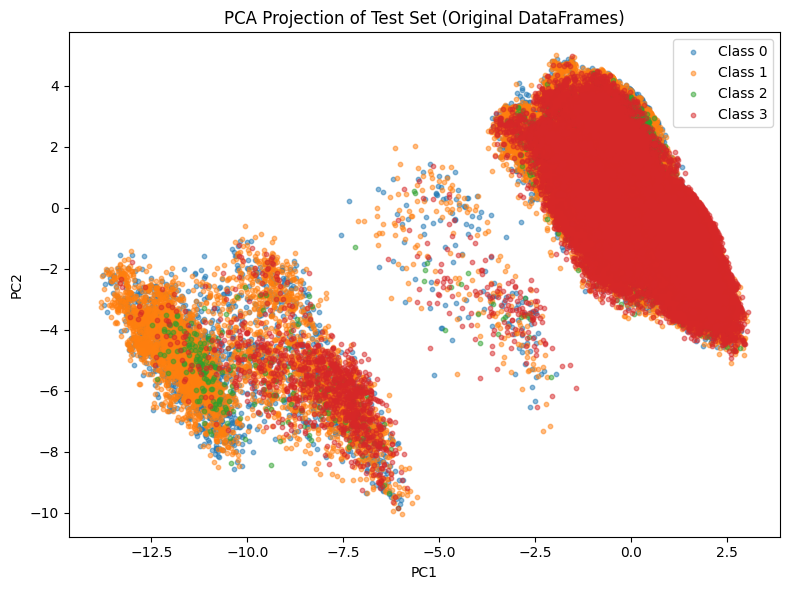

In [25]:
# Fitting PCA on the original training Datasets

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Scale original train and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

# Fit PCA on original training set
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# Visualize PCA projection of test set (true classes)
plt.figure(figsize=(8,6))
for c in np.unique(y_test_enc):
    plt.scatter(
        X_test_pca[y_test_enc == c, 0],
        X_test_pca[y_test_enc == c, 1],
        label=f"Class {c}",
        alpha=0.5,
        s=10
    )
plt.legend()
plt.title("PCA Projection of Test Set (Original DataFrames)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

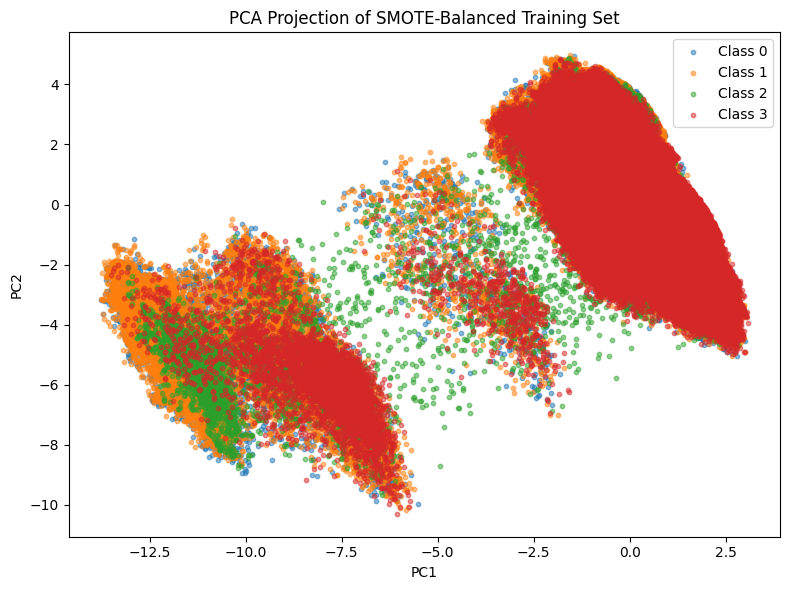

In [26]:
# Visualize PCA projection of SMOTE-balanced training set

X_train_cs85_scaled = scaler.transform(X_train_cs85)
X_train_cs85_pca = pca.transform(X_train_cs85_scaled)

plt.figure(figsize=(8,6))
for c in np.unique(y_train_cs85):
    plt.scatter(
        X_train_cs85_pca[y_train_cs85 == c, 0],
        X_train_cs85_pca[y_train_cs85 == c, 1],
        label=f"Class {c}",
        alpha=0.5,
        s=10
    )
plt.legend()
plt.title("PCA Projection of SMOTE-Balanced Training Set")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [27]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.05235472 0.04734749]
Total variance explained: 0.09970220515469153


### SHAP feature‑importance barplot 


In [ ]:
import shap

#  final tuned LightGBM model
explainer = shap.TreeExplainer(best_lgbm)

# SHAP values for each class
shap_values = explainer.shap_values(X_test_lgbm)


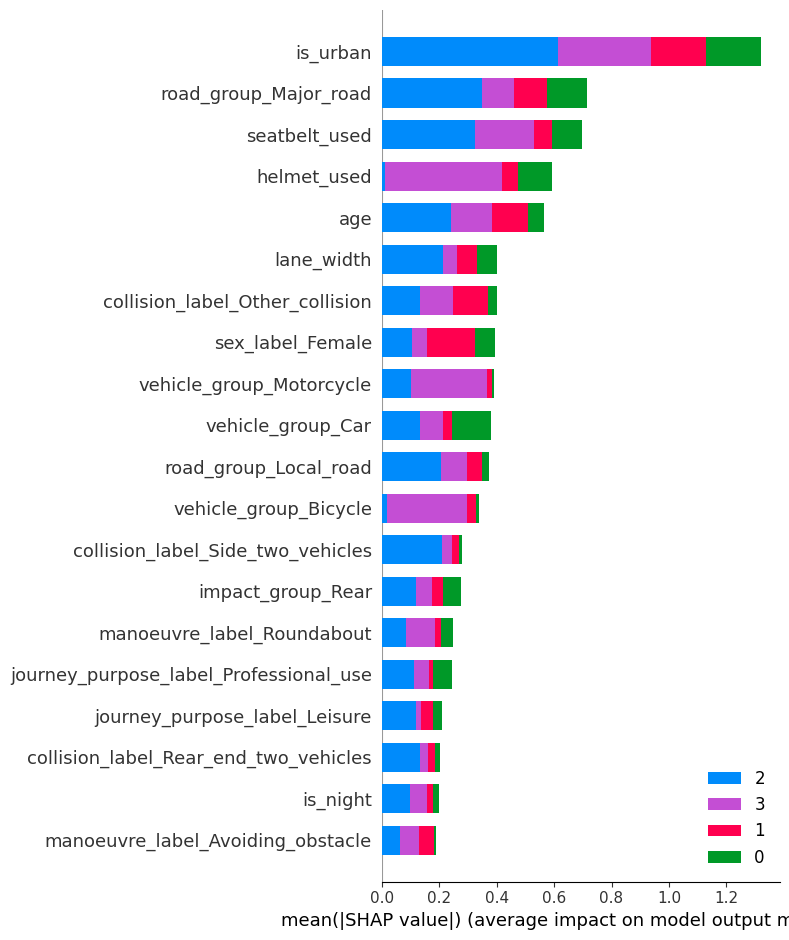

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_lgbm,
    plot_type="bar",
    class_names=["0", "1", "2", "3"]
)

### Implement SHAP findings and retrain the model

In [ ]:
print("SHAP array shape:", shap_values[0].shape)
print("Number of model features:", len(best_lgbm.feature_name_))
print("Number of X_test_lgbm columns:", X_test_lgbm.shape[1])

SHAP array shape: (85, 4)
Number of model features: 85
Number of X_test_lgbm columns: 85


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# ---------------------------------------------------------
# 1. Rebuild SHAP feature importance from existing shap_values
# ---------------------------------------------------------

# shap_values is a list: one array per class
# each array has shape (n_samples, n_features)

shap_abs_mean = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values],
    axis=0
)

feature_importance = pd.DataFrame({
    "feature": best_lgbm.feature_name_,
    "importance": shap_abs_mean
}).sort_values("importance", ascending=False)

print("Top 10 features:\n", feature_importance.head(10))


# ---------------------------------------------------------
# 2. Select top N features
# ---------------------------------------------------------

TOP_N = 40
top_features = feature_importance.head(TOP_N)["feature"].tolist()

print("\nSelected top features:\n", top_features)


# ---------------------------------------------------------
# 3. Subset training and test sets
# ---------------------------------------------------------

X_train_reduced = X_train_cs85[top_features]
X_test_reduced  = X_test_lgbm[top_features]


# ---------------------------------------------------------
# 4. Retrain LightGBM using your tuned parameters
# ---------------------------------------------------------

best_lgbm.fit(X_train_reduced, y_train_cs85)


# ---------------------------------------------------------
# 5. Evaluate the reduced model
# ---------------------------------------------------------

y_pred = best_lgbm.predict(X_test_reduced)
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred))